#  UNIVERSIDAD AUTÓNOMA METROPOLITANA UNIDAD IZTAPALAPA <br> Licenciatura en Computación <br> Temas Selectos de Bases de Datos

## Proyecto Final

### Integrantes: 

- Alejandro Estrada Basilio (2203043898)
- Cielo Mariel Huerta Escobar (2223046073)
- Ricardo Palomino Bravo (2233013059)

_______

## **1. Planteamiento del problema**


### **Título**: Breve estudio de Víctimas en México del periodo 2015 - 2025

### **Justificación**
#### - *¿Por qué les interesó este tema o conjunto de datos?*

  **R.** Debido a que es un tema relevante para todos los mexicanos y consideramos que es importante estar al tanto de la evolución de la violencia y las víctimas derivadas de ello. Además de percartarnos por cuenta propia de cómo se comportan los datos y no permitir que se nos entreguen análisis amañados. 

#### - *¿Qué aspectos te parecieron curiosos o importantes de analizar?*

  **R.** Analizar el impacto que tiene el sexo en las víctimas, además de observar la repercusión del tiempo en el crecimiento (o decremento) de la cantidad de víctimas a nivel nacional. 

#### - *¿Qué utilidad o aplicación imaginarias o reales podría tener tu análisis? (Es decir a futuro para qué sirve analizar estos datos)*


 **R.** Si bien el alcance de este proyecto no es el adecaudo para las ambiviones y preguntas que podrían realizarse con los datos disponibles, consideramos que con el tiempo suficiente, un proyecto estadístico de esta índole podría funcionar para visibilzar la tendencia de las inicidencias delicitivas y sus consecuentes víctimas. Además de que el hecho de realizar un análisis independiente de los medios oficiales, trae a la mesa una perspectiva diferente a los objetivos impuestos por el oficialismo. 


## **2. Obtención de datos.**


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv('Estatal-Víctimas-2015-2025_may2026.csv', encoding='latin1')

#copia del dataset
df_copia = df.copy()

# Cabecera
df_copia.head()



,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),0,...,0,0,1,0,0,1,0,0,0,0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# Cola
df_copia.tail()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
80955,2025,32,Zacatecas,Libertad personal,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,No identificado,No identificado,0,...,0,0,0,0,2,2,0,0,0,0
80956,2025,32,Zacatecas,El patrimonio,Extorsión,Extorsión,Extorsión,No identificado,No identificado,0,...,2,1,0,0,0,0,1,0,0,2
80957,2025,32,Zacatecas,La sociedad,Corrupción de menores,Corrupción de menores,Corrupción de menores,No identificado,No identificado,1,...,1,0,1,0,1,0,0,0,0,1
80958,2025,32,Zacatecas,La sociedad,Trata de personas,Trata de personas,Trata de personas,No identificado,No identificado,0,...,0,0,2,0,0,0,0,0,0,0
80959,2025,32,Zacatecas,La sociedad,Otros delitos contra la sociedad,Otros delitos contra la sociedad,Otros delitos contra la sociedad,No identificado,No identificado,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Se tienen 80,960 filas y 21 columnas
df_copia.shape

(80960, 21)

In [23]:

# Quiero saber los nombres de cada entidad para hacer el mapeo con la poblacion de estads
print(df_copia.columns)      


Index(['Año', 'Clave_Ent', 'Entidad', 'Bien jurídico afectado',
       'Tipo de delito', 'Subtipo de delito', 'Modalidad', 'Sexo',
       'Rango de edad', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
       'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
      dtype='object')


In [24]:
# Mostramos los valores únicos de las columnas que consideramos necesarios

print(f"-> Valores únicos de 'Bien jurídico afectado': {df_copia['Bien jurídico afectado'].unique()}\n")
print(f"-> Valores únicos de 'Tipo de delito': {df_copia['Tipo de delito'].unique()}\n")
print(f"-> Valores únicos de 'Subtipo de delito': {df_copia['Subtipo de delito'].unique()}\n")
print(f"-> Valores únicos de 'Modalidad': {df_copia['Modalidad'].unique()}\n")
print(f"-> Valores únicos de 'Sexo': {df_copia['Sexo'].unique()}\n")
print(f"-> Valores únicos de 'Rango de edad': {df_copia['Rango de edad'].unique()}")

-> Valores únicos de 'Bien jurídico afectado': ['La vida y la Integridad corporal' 'Libertad personal' 'El patrimonio'
 'La sociedad']

-> Valores únicos de 'Tipo de delito': ['Homicidio' 'Lesiones' 'Feminicidio'
 'Otros delitos que atentan contra la vida y la integridad corporal'
 'Secuestro' 'Tráfico de menores' 'Rapto'
 'Otros delitos que atentan contra la libertad personal' 'Extorsión'
 'Corrupción de menores' 'Trata de personas'
 'Otros delitos contra la sociedad' 'Aborto']

-> Valores únicos de 'Subtipo de delito': ['Homicidio doloso' 'Homicidio culposo' 'Lesiones dolosas'
 'Lesiones culposas' 'Feminicidio'
 'Otros delitos que atentan contra la vida y la integridad corporal'
 'Secuestro' 'Tráfico de menores' 'Rapto'
 'Otros delitos que atentan contra la libertad personal' 'Extorsión'
 'Corrupción de menores' 'Trata de personas'
 'Otros delitos contra la sociedad' 'Aborto']

-> Valores únicos de 'Modalidad': ['Con arma de fuego' 'Con arma blanca' 'Con otro elemento'
 'No especific

## **3. Limpieza y preparación de datos.**


In [25]:
# Observamos la cantidad de nulos y los tipos de dato de cada columna
df_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80960 entries, 0 to 80959
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Año                     80960 non-null  int64 
 1   Clave_Ent               80960 non-null  int64 
 2   Entidad                 80960 non-null  object
 3   Bien jurídico afectado  80960 non-null  object
 4   Tipo de delito          80960 non-null  object
 5   Subtipo de delito       80960 non-null  object
 6   Modalidad               80960 non-null  object
 7   Sexo                    80960 non-null  object
 8   Rango de edad           80960 non-null  object
 9   Enero                   80960 non-null  int64 
 10  Febrero                 80960 non-null  int64 
 11  Marzo                   80960 non-null  int64 
 12  Abril                   80960 non-null  int64 
 13  Mayo                    80960 non-null  int64 
 14  Junio                   80960 non-null  int64 
 15  Ju

In [26]:
# Verificaremos si hay valores duplicados (no hay)
df_copia.duplicated().sum() 

np.int64(0)

### **Resumen de esta fase**: 
#### En el análisis inicial de nuestro *dataset* pudimos ver que **no hay valores nulos** y que los datos no necesitan de una conversión a otro tipo ya que **tienen el formato adecuado para ser usados**. Por otro lado, pudimos observar que **no hay valores duplicados** y que **no necesitamos eliminar alguna columna**. En tanto al agregado de variables y/o columnas, estás se agregarán al momento de responder cada una de las preguntas planteadas. 

______

## *A continuación, condensaremos los puntos ***4. Análisis exploratorio***, ***5. Modelado*** y ***6. Evaluación del Modelo y Supuestos*** ya que las respuestas a nuestras preguntas contienen en sí mismas cada una de estas secciones, por lo que, dadas las necesidades particulares de cada cuestionamiento, se mostrarán las métricas, gráficas y evaluaciones pertinentes.*

___

# **1. ¿La media de la incidencia delictiva mensual cambió significativamente entre el periodo pre-pandemia, pandemia y post-pandemia?** 

### *Periodos:*

### - *Pre-pandemia: 2015 - 2019* <br>
### - *Pandemia: 2020 - 2021* <br>
### - *Post-pandemia: 2022 - 2025* <br>

### *Usamos la tasa de delitos por cada 100,000 habitantes en vez del total, para que los estados con más población no dominen la comparación.*

### *Los datos que se muestran a continuación forman parte de los proporcionados en el **último censo que hizo el INEGI en el 2020.***

### **URL del censo**: https://www.inegi.org.mx/programas/ccpv/2020/

In [27]:
poblacion_estados = {'Aguascalientes':1425607,'Baja California':3769020,'Baja California Sur':798447,'Campeche':928363,
                     'Coahuila de Zaragoza':3146771,'Colima':731391,'Chiapas':5543828,'Chihuahua':3741869,'Ciudad de México':9209944,
                     'Durango':1832650,'Guanajuato':6166934,'Guerrero':3540685,'Hidalgo':3082841,'Jalisco':8348151,'México':16992418,
                     'Michoacán de Ocampo':4748846,'Morelos':1971520,'Nayarit':1235456,'Nuevo León':5784442,'Oaxaca':4132148,'Puebla':6583278,
                     'Querétaro':2368467,'Quintana Roo':1857985,'San Luis Potosí':2822255,'Sinaloa':3026943,'Sonora':2944840,'Tabasco':2402598,
                     'Tamaulipas':3527735,'Tlaxcala':1342977,'Veracruz de Ignacio de la Llave':8062579,'Yucatán':2320898,'Zacatecas':1622138}

In [28]:
df_pregunta1 = df.copy()

In [29]:
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

In [30]:
# Sumamos todos los tipos de delito por Año y Entidad
agrupado = df_pregunta1.groupby(['Año', 'Entidad'])[meses].sum().reset_index()

# Convertimos los meses (que son columnas) en filas, para tener una fila por Entidad-Año-Mes
df_largo = agrupado.melt(id_vars=['Año', 'Entidad'], value_vars=meses, var_name='Mes', value_name='Delitos')

# Tasa = delitos / poblacion x 100,000
df_largo['Poblacion'] = df_largo['Entidad'].map(poblacion_estados)
df_largo['Tasa'] = df_largo['Delitos'] / df_largo['Poblacion'] * 100000
df_largo.head()

,Año,Entidad,Mes,Delitos,Poblacion,Tasa
0,2015,Aguascalientes,Enero,275,1425607,19.290029
1,2015,Baja California,Enero,1428,3769020,37.887833
2,2015,Baja California Sur,Enero,137,798447,17.158309
3,2015,Campeche,Enero,24,928363,2.585196
4,2015,Chiapas,Enero,295,5543828,5.321233


In [31]:
# Etiquetamos cada año con su periodo
def clasificar_periodo(anio):
    if anio <= 2019:
        return 'Pre-pandemia'
    elif anio <= 2021:
        return 'Pandemia'
    else:
        return 'Post-pandemia'

df_largo['Periodo'] = df_largo['Año'].apply(clasificar_periodo)
df_largo

,Año,Entidad,Mes,Delitos,Poblacion,Tasa,Periodo
0,2015,Aguascalientes,Enero,275,1425607,19.290029,Pre-pandemia
1,2015,Baja California,Enero,1428,3769020,37.887833,Pre-pandemia
2,2015,Baja California Sur,Enero,137,798447,17.158309,Pre-pandemia
3,2015,Campeche,Enero,24,928363,2.585196,Pre-pandemia
4,2015,Chiapas,Enero,295,5543828,5.321233,Pre-pandemia
...,...,...,...,...,...,...,...
4219,2025,Tamaulipas,Diciembre,420,3527735,11.905656,Post-pandemia
4220,2025,Tlaxcala,Diciembre,31,1342977,2.308305,Post-pandemia
4221,2025,Veracruz de Ignacio de la Llave,Diciembre,1281,8062579,15.888216,Post-pandemia
4222,2025,Yucatán,Diciembre,53,2320898,2.283599,Post-pandemia


In [32]:
# Tabla resumen: cuántos datos hay por periodo y cuál es la tasa promedio
tabla_resumen = df_largo.groupby('Periodo')['Tasa'].agg(['count', 'mean', 'std']).reindex(['Pre-pandemia', 'Pandemia', 'Post-pandemia'])
tabla_resumen


#cada fila de df_largo representa "en tal estado, en tal mes de tal año, hubo tal tasa de delitos
#count solo cuenta cuántas de esas filas hay en cada periodo de tiempo, no cuántos delitos hubo.

,count,mean,std
Periodo,,,
Pre-pandemia,1920,19.607108,9.776527
Pandemia,768,20.835864,10.642619
Post-pandemia,1536,24.281649,12.311139


### *Usamos un diagrama de caja para tener un un vistazo si los tres periodos se ven diferentes entre sí, antes de la prueba t-student*

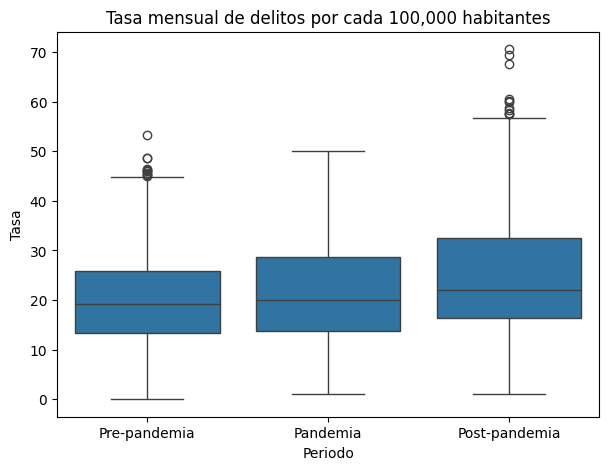

In [33]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_largo, x='Periodo', y='Tasa', order=['Pre-pandemia', 'Pandemia', 'Post-pandemia'])
plt.title('Tasa mensual de delitos por cada 100,000 habitantes')
plt.show()

## **Normalidad**

### *Revisamos si la tasa se comporta normal en cada periodo, con la prueba de Shapiro-Wilk.*

In [34]:
from scipy import stats

filas = []
for periodo in ['Pre-pandemia', 'Pandemia', 'Post-pandemia']: # Recorremos los 3 periodos y hacemos prueba Shapiro - Wilk
    datos = df_largo.loc[df_largo['Periodo'] == periodo, 'Tasa']
    stat, p = stats.shapiro(datos)
    filas.append({'Periodo': periodo, 'N': len(datos), 'p-valor': p, 'Normal': 'No' if p < 0.05 else 'Si'})

tabla_normalidad = pd.DataFrame(filas)
tabla_normalidad

,Periodo,N,p-valor,Normal
0,Pre-pandemia,1920,9.844569e-14,No
1,Pandemia,768,9.481954e-09,No
2,Post-pandemia,1536,6.309759e-15,No


### *En los tres periodos **el p-valor es menor a 0.05**, así que no hay normalidad perfecta. Como cada grupo tiene bastantes datos (n > 700), lo dejamos pasar y usamos la prueba t de todos modos.*

In [35]:
# Separamos la tasa de cada periodo
pre = df_largo.loc[df_largo['Periodo'] == 'Pre-pandemia', 'Tasa']
pandemia = df_largo.loc[df_largo['Periodo'] == 'Pandemia', 'Tasa']
post = df_largo.loc[df_largo['Periodo'] == 'Post-pandemia', 'Tasa']

# Comparamos los periodos de dos en dos con t-student
comparaciones = [('Pre-pandemia vs Pandemia', pre, pandemia),
                  ('Pandemia vs Post-pandemia', pandemia, post),
                  ('Pre-pandemia vs Post-pandemia', pre, post)]

filas = []
for nombre, a, b in comparaciones:
    t, p = stats.ttest_ind(a, b)
    filas.append({'Comparación': nombre, 't': round(t, 3), 'p-valor': p, 'Significativo (p<0.05)': 'Si' if p < 0.05 else 'No'})

tabla_ttest = pd.DataFrame(filas)
tabla_ttest

,Comparación,t,p-valor,Significativo (p<0.05)
0,Pre-pandemia vs Pandemia,-2.869,4.151009e-03,Si
1,Pandemia vs Post-pandemia,-6.618,4.516151e-11,Si
2,Pre-pandemia vs Post-pandemia,-12.442,8.555403e-35,Si


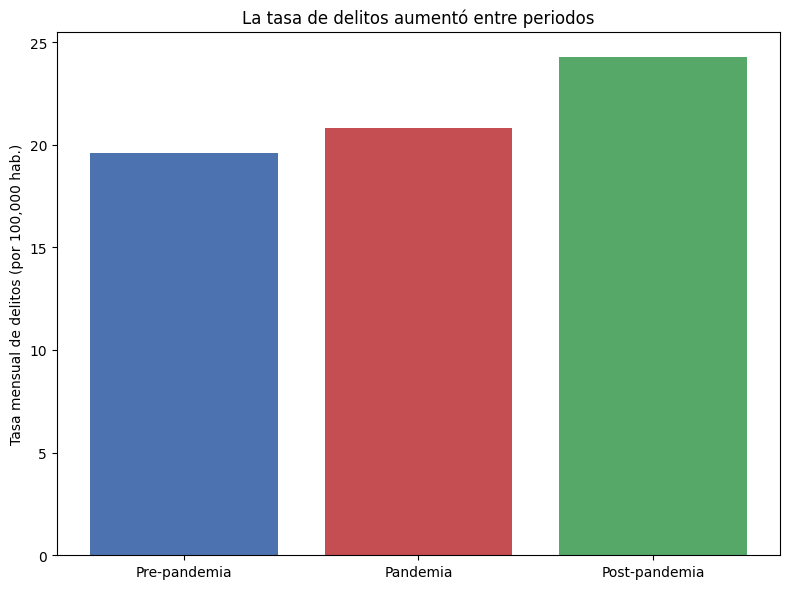

In [36]:
orden = ['Pre-pandemia', 'Pandemia', 'Post-pandemia']
medias = df_largo.groupby('Periodo')['Tasa'].mean().reindex(orden)
errores = df_largo.groupby('Periodo')['Tasa'].sem().reindex(orden)  # error estándar del promedio

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(orden, medias, capsize=6, color=['#4C72B0', '#C44E52', '#55A868'])
ax.set_ylabel('Tasa mensual de delitos (por 100,000 hab.)')
ax.set_title('La tasa de delitos aumentó entre periodos')
plt.tight_layout()
plt.show()

### ***Conclusión**: las tres comparaciones dan p-valor menor a 0.05, o sea que sí hubo un cambio significativo en la tasa mensual de delitos entre pre-pandemia, pandemia y post-pandemia. Viendo la tabla de medias, la tasa fue subiendo en cada periodo (post-pandemia es la más alta)*.

_____

# **2. ¿Existe una diferencia estadísticamente significativa en la media de homicidios entre los diferentes meses del año?**

### *Preparamos los datos para poder calcular la tasa de homicidios por cada 100,000 habitantes*

In [41]:
import pandas as pd
import scipy.stats as stats
from scipy.stats import skew, kurtosis
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos y preparar diccionario 
df = pd.read_csv('Estatal-Víctimas-2015-2025_may2026.csv', encoding='latin1')

poblacion_estados = {'Aguascalientes':1425607,'Baja California':3769020,'Baja California Sur':798447,'Campeche':928363,
                     'Coahuila de Zaragoza':3146771,'Colima':731391,'Chiapas':5543828,'Chihuahua':3741869,'Ciudad de México':9209944,
                     'Durango':1832650,'Guanajuato':6166934,'Guerrero':3540685,'Hidalgo':3082841,'Jalisco':8348151,'México':16992418,
                     'Michoacán de Ocampo':4748846,'Morelos':1971520,'Nayarit':1235456,'Nuevo León':5784442,'Oaxaca':4132148,'Puebla':6583278,
                     'Querétaro':2368467,'Quintana Roo':1857985,'San Luis Potosí':2822255,'Sinaloa':3026943,'Sonora':2944840,'Tabasco':2402598,
                     'Tamaulipas':3527735,'Tlaxcala':1342977,'Veracruz de Ignacio de la Llave':8062579,'Yucatán':2320898,'Zacatecas':1622138}

# Filtrar solo Homicidios
df_hom = df[df['Tipo de delito'] == 'Homicidio']

# Agrupar por estado y año, sumando los meses
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

df_agrupado = df_hom.groupby(['Año', 'Entidad'])[meses].sum().reset_index()

# usar 'melt' en el dataframe para que 'Mes' sea una columna
df_melt = df_agrupado.melt(id_vars=['Año', 'Entidad'], 
                            value_vars=meses, 
                            var_name='Mes', 
                            value_name='Total_Homicidios')

#  Mapear población y calcular tasa
df_melt['Poblacion'] = df_melt['Entidad'].map(poblacion_estados)
df_melt['Tasa_Hom_100k'] = (df_melt['Total_Homicidios'] / df_melt['Poblacion']) * 100000
df_melt['Tasa_Hom_100k'].describe()

count    4224.000000
mean        3.407811
std         2.353092
min         0.000000
25%         1.726395
50%         2.636759
75%         4.592182
max        19.287442
Name: Tasa_Hom_100k, dtype: float64

### *Evaluamos la normalidad mediante la prueba de Shapiro-Wilk*

Estadístico Shapiro-Wilk: 0.883
p-valor: 7.971203477692858e-49
Los datos NO siguen una distribución normal.
-> Asimetría (skew): 1.393
-> Curtosis: 2.393


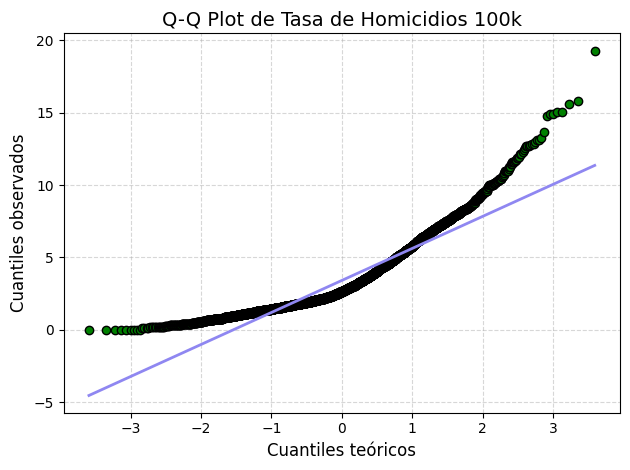

In [43]:
# Prueba de Shapiro-Wilk para evaluar normalidad
stat_shapiro, p_shapiro = stats.shapiro(df_melt['Tasa_Hom_100k'])

print(f"Estadístico Shapiro-Wilk: {stat_shapiro:.3f}")
print(f"p-valor: {p_shapiro}")

if p_shapiro < 0.05:
    print("Los datos NO siguen una distribución normal.")
else:
    print("No se rechaza la normalidad (distribución normal posible).")

print(f"-> Asimetría (skew): {skew(df_melt['Tasa_Hom_100k']):.3f}")
print(f"-> Curtosis: {kurtosis(df_melt['Tasa_Hom_100k']):.3f}")

ax = plt.gca() 
res = scipy.stats.probplot(df_melt['Tasa_Hom_100k'], dist="norm", plot=ax)
# Personalización
ax.get_lines()[1].set_color('#8F87F1')   # línea de referencia
ax.get_lines()[1].set_linewidth(2)
ax.get_lines()[0].set_markerfacecolor('green')
ax.get_lines()[0].set_markeredgecolor('black')

plt.title("Q-Q Plot de Tasa de Homicidios 100k", fontsize=14)
plt.xlabel("Cuantiles teóricos", fontsize=12)
plt.ylabel("Cuantiles observados", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

*-> Observamos una **asimetría positiva**, esto significa que hay una cola a la derecha un poco mas pronunciada.*

*-> **Curtosis positivo** señala colas más pesadas y datos más concentrados en el centro.*

*-> El ANOVA asume que la distribución de la población es normal, pero es  robusto ante violaciones de normalidad si la  muestra es grande. Como se tiene un $N = 4224$ (con $352$ observaciones por mes), el **Teorema del Límite Central entra en acción**. Este teorema dice que, con muestras grandes (generalmente $N > 30$ por grupo), la distribución de las medias muestrales será aproximadamente normal de todos modos, incluso si los datos originales tienen asimetría*

Resultado ANOVA de una vía:
Estadístico F: 0.760
Valor p: 0.681

Resultado Prueba de Kruskal-Wallis:
Estadístico H: 10.414
Valor p: 0.494



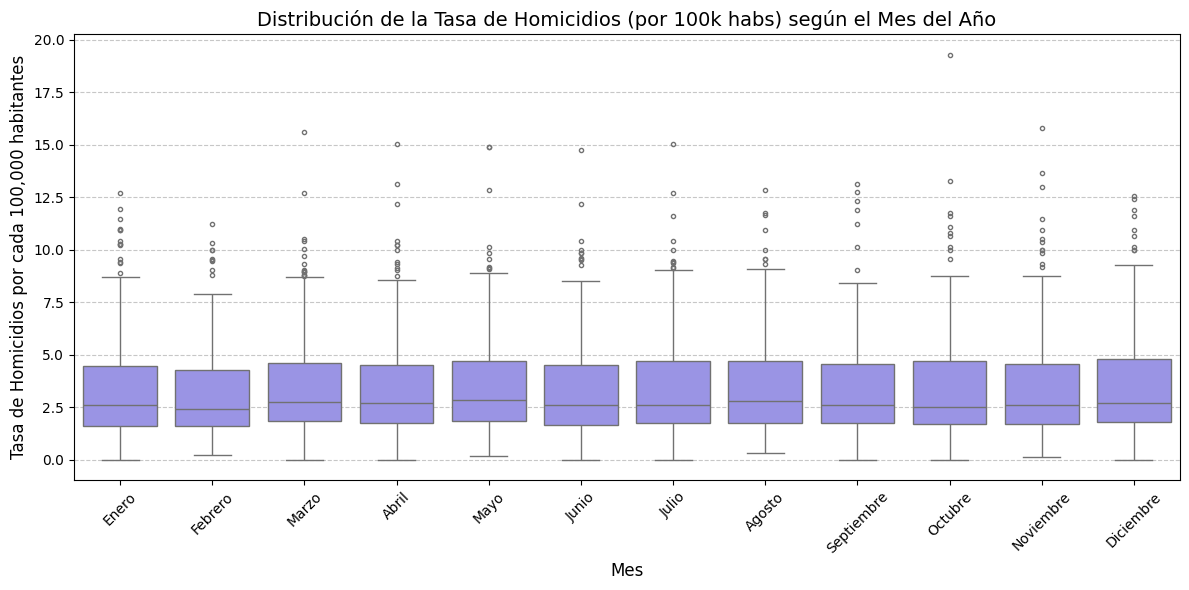

In [44]:
df_melt['Mes'] = pd.Categorical(df_melt['Mes'], categories=meses, ordered=True)

grupos_por_mes = [grupo['Tasa_Hom_100k'].values for nombre, grupo in df_melt.groupby('Mes', observed=False)]

# Ejecutar Análisis Paramétrico (ANOVA)
f_stat, p_anova = stats.f_oneway(*grupos_por_mes)
print(f"Resultado ANOVA de una vía:")
print(f"Estadístico F: {f_stat:.3f}")
print(f"Valor p: {p_anova:.3f}\n")

# Ejecutar Análisis No Paramétrico (Kruskal-Wallis) por la falla de normalidad
h_stat, p_kruskal = stats.kruskal(*grupos_por_mes)
print(f"Resultado Prueba de Kruskal-Wallis:")
print(f"Estadístico H: {h_stat:.3f}")
print(f"Valor p: {p_kruskal:.3f}\n")

# Crear un Boxplot para visualizar la distribución mensual
plt.figure(figsize=(12, 6))
sns.boxplot(x='Mes', y='Tasa_Hom_100k', data=df_melt, color='#8F87F1', fliersize=3)

# Personalización del gráfico
plt.title('Distribución de la Tasa de Homicidios (por 100k habs) según el Mes del Año', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Tasa de Homicidios por cada 100,000 habitantes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## *Análisis de resultados* 

-> **Evaluación de Hipótesis (ANOVA)**: Al aplicar un Análisis de Varianza (ANOVA) de una vía para evaluar las diferencias en la tasa de homicidios entre los meses del año, se obtuvo un valor $p$ de $0.681$ ($F = 0.760$). Ya que el valor $p$ es superior al nivel de significancia ($0.05$), no se puede rechazar la hipótesis nula. **Esto indica que no hay evidencia estadísticamente significativa para afirmar que el mes del año afecta la media de la tasa de homicidios a nivel nacional**.

-> **Kruskal-Wallis como confirmación**: Debido a que las pruebas iniciales violaban el supuesto de normalidad estricta, se procedió a usar este método no paramétrico como confirmación de ANOVA. . El resultado arrojó un valor $p$ de $0.494$ ($H = 10.414$), confirmando la conclusión : **no existen diferencias significativas en la distribución de la violencia letal entre meses**.

-> **Análisis del gráfico (Boxplot)**: 

- Las medianas se mantienen relativamente constantes mes con mes (tasas de entre 2.5 y 3.0)

- Observamos gran dispersion entre los datos dentro de cada mes: la altura del rectángulo representa el 50% central de los estados. El tamaño de la caja es casi idéntico todos los meses, lo que confirma que el problema afecta de manera similar todo el año. Cuanto mas grande la caja, mayor es la variacion. 

- Los valores atípicos representan los estados con tasas de homicidio extremadamente altas. Esta asimetría arrastra la media hacia arriba pero estos valores ocurren de manera constante todos los meses, lo que genera mucho ruido e impide percibir una variación estacional en homicidios

_____


# **3. ¿La proporción o el promedio de victimas masculinas vs femeninas difiere significativamente?**

In [4]:
# importacion de librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


#lectura de datasets
df_victimas = pd.read_csv('Estatal-Víctimas-2015-2025_may2026.csv', encoding='latin1')
df_inegi = pd.read_excel('INEGI_exporta_17_7_2026_15_49_30_limpio.xlsx')

#copia de los dataset
df_copia = df_victimas.copy()
df_copy = df_inegi.copy()


#renombrando columans del df_inegi
df_inegi = df_inegi.rename(columns={
    ' Total': 'Entidad',
    ' Total.1': 'Poblacion'
})

print(df_inegi)



#LIMPIANDO DETALLES DE LOS NOMBRES DE LAS ENTIDADES DEL df_entidad: #aqui se elimino un espacio que tenia este estado
df_inegi["Entidad"] = df_inegi["Entidad"].str.strip()



meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

#AGRUPANDO DATOS
resultado = (
    df_copia
    .groupby(["Entidad", "Año", "Sexo"])[meses]
    .sum()
    .reset_index()
)

#print(resultado)





#  suma cada columna de enero a diciembre de cada estado
resultado["Total"] = resultado[meses].sum(axis=1)
print(resultado['Total'])

    Unnamed: 0                           Entidad  Poblacion   Hombres  \
0            1                    Aguascalientes    1425607    696683   
1            2                   Baja California    3769020   1900589   
2            3               Baja California Sur     798447    405879   
3            4                          Campeche     928363    456939   
4            5              Coahuila de Zaragoza    3146771   1563669   
5            6                            Colima     731391    360622   
6            7                           Chiapas    5543828   2705947   
7            8                         Chihuahua    3741869   1853822   
8            9                  Ciudad de México    9209944   4404927   
9           10                           Durango    1832650    904866   
10          11                        Guanajuato    6166934   2996454   
11          12                          Guerrero    3540685   1700612   
12          13                           Hidalgo   

_____

In [5]:
#construyendo el diccionario

poblacion_estados = {'Aguascalientes':1425607,'Baja California':3769020,'Baja California Sur':798447,'Campeche':928363,
                     'Coahuila de Zaragoza':3146771,'Colima':731391,'Chiapas':5543828,'Chihuahua':3741869,'Ciudad de México':9209944,
                     'Durango':1832650,'Guanajuato':6166934,'Guerrero':3540685,'Hidalgo':3082841,'Jalisco':8348151,'México':16992418,
                     'Michoacán de Ocampo':4748846,'Morelos':1971520,'Nayarit':1235456,'Nuevo León':5784442,'Oaxaca':4132148,'Puebla':6583278,
                     'Querétaro':2368467,'Quintana Roo':1857985,'San Luis Potosí':2822255,'Sinaloa':3026943,'Sonora':2944840,'Tabasco':2402598,
                     'Tamaulipas':3527735,'Tlaxcala':1342977,'Veracruz de Ignacio de la Llave':8062579,'Yucatán':2320898,'Zacatecas':1622138}

In [10]:
#lo que hace .map() es: busca cada dato en el diccionario, ejemplo:
#para 'puebla' busca 'poblacion_estados["Puebla"]' y encuentra: '6583278' y agrega el numero en la columna 'Poblacion'

resultado["Poblacion"] = resultado["Entidad"].map(poblacion_estados)


#excluyendo los datos de 'no identificado' de la columna 'Sexo'
df_filtrado = df_copia[df_copia["Sexo"] != "No identificado"]
print(df_filtrado['Sexo'])

0         Mujer
1         Mujer
2         Mujer
3         Mujer
4         Mujer
          ...  
80923    Hombre
80924    Hombre
80925    Hombre
80926    Hombre
80927    Hombre
Name: Sexo, Length: 69696, dtype: object


In [7]:
#lisita con los meses
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

#aqui simplemente filtra por 'Entidad' y 'Sexo'
resultado = (
    df_filtrado
    .groupby(["Entidad", "Sexo"])[meses]
    .sum()
    .reset_index()
)

print(resultado)

                            Entidad    Sexo  Enero  Febrero  Marzo  Abril  \
0                    Aguascalientes  Hombre    286      283    303    320   
1                    Aguascalientes   Mujer     92      113    107    105   
2                   Baja California  Hombre   8352     8264   9365   9207   
3                   Baja California   Mujer   5100     5459   6019   5815   
4               Baja California Sur  Hombre   1308     1227   1426   1381   
..                              ...     ...    ...      ...    ...    ...   
59  Veracruz de Ignacio de la Llave   Mujer   3079     3446   4067   3984   
60                          Yucatán  Hombre   1150     1212   1375   1246   
61                          Yucatán   Mujer    401      295    363    460   
62                        Zacatecas  Hombre   2811     2655   2954   2820   
63                        Zacatecas   Mujer   1287     1177   1453   1467   

    Mayo  Junio  Julio  Agosto  Septiembre  Octubre  Noviembre  Diciembre  

In [8]:
#suma los datos de incidentes de enero a diciembre,  esto calcula el numerador de la tasa
resultado["Total"] = resultado[meses].sum(axis=1)
print(resultado['Total'])

0       3535
1       1335
2     113358
3      73429
4      17314
       ...  
59     44120
60     12982
61      4353
62     35580
63     17482
Name: Total, Length: 64, dtype: int64


In [11]:
#calculo de la tasa
resultado["Tasa_pregunta3"] = (
    resultado["Total"] / resultado["Poblacion"]
) * 100000

In [12]:
#separacion de datos de hombres
hombres = resultado[resultado["Sexo"] == "Hombre"]["Tasa_pregunta3"]

#separacion de datos de mujeres para poder compararlos despues
mujeres = resultado[resultado['Sexo'] == 'Mujer']['Tasa_pregunta3']


Aquí finaliza la etapa de preparación de los datos y empieza la parte estadística.
Lo que se hace es:

Revisar si ambas muestras siguen una distribución aproximadamente normal.
Si sí entonces usar una prueba t para dos muestras independientes.


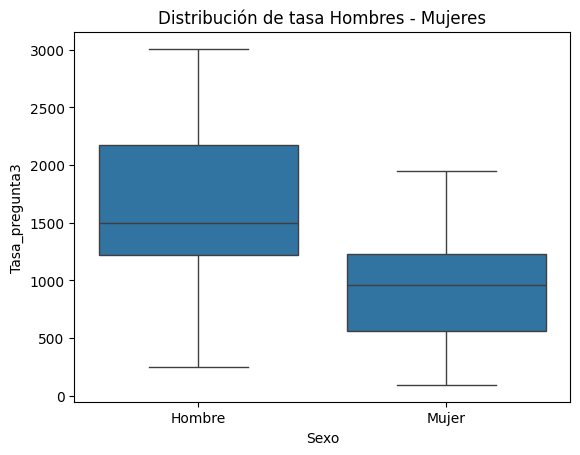

In [32]:
#grafica de la distribucion de los datos de la tasa entre hombres y mujeres
sns.boxplot(data=resultado,
            x="Sexo",
            y="Tasa_pregunta3")
plt.title('Distribución de tasa Hombres - Mujeres')
plt.show()

# **Hipótesis:**
-> **Hipótesis nula** (H₀): Los datos siguen una distribución normal.

-> **Por el contrario**, (H₁): Los datos no siguen una distribución normal.

### CRITERIO:

-> **Si p > 0.05**
No hay evidencia suficiente para decir que los datos no son normales.

Se considera que los datos pueden tratarse como normales.



-> **Si p ≤ 0.05**
Se rechaza la hipótesis de normalidad.

Se concluye que los datos no siguen una distribución normal.

In [ ]:
#prueba de normalidad Shapiro Wilk para ver si tienen una distribución normal
from scipy.stats import shapiro

shapiro(resultado['Tasa_pregunta3'])

ShapiroResult(statistic=np.float64(0.9713899638324678), pvalue=np.float64(0.1428690999765505))

# **En este caso como:**
#  **p = 0.1429 > 0.05**

Los datos de la columna Tasa_pregunta3 tienen una **distribución normal**.


# **CONCLUSION DE LA NORMALIDAD:**

Se aplicó la prueba de normalidad de **Shapiro-Wilk** sobre la variable Tasa_pregunta3. Se obtuvo un valor de p = 0.1429, superior al nivel de significancia de 0.05.
Por lo tanto, **no se rechaza la hipótesis nula y se concluye que los datos son compatibles con una distribución normal**.

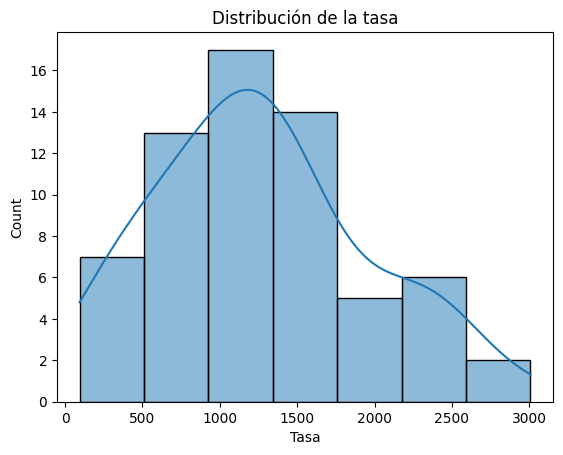

In [15]:
#visualizacion 
sns.histplot(resultado["Tasa_pregunta3"], kde=True)

plt.xlabel("Tasa")
plt.title("Distribución de la tasa")
plt.show()

In [17]:
# calcula el coeficiente de asimetría (skewness) de la distribución de la variable
print(resultado['Tasa_pregunta3'].skew()) #ESTO ES LOS DATOS EN CONJUNTO

0.422031569358874



### **Criterios:**

-> **Entre -0.5 y 0.5 → aproximadamente simétrica**.

-> **Entre -1 y -0.5 o entre 0.5 y 1 → asimetría moderada**.

-> **Mayor a 1 → asimetría fuerte**.

### En este caso:
**0.42** es perfectamente compatible con la conclusión de que **la distribución es aproximadamente normal**.



Dado que el análisis consiste en comparar dos grupos (hombres y mujeres), también se evaluó la normalidad de cada grupo por separado

In [18]:
#ahora haciendo prueba pro SEPARADO de datos para hombre y mujer
hombres = resultado[resultado["Sexo"] == "Hombre"]["Tasa_pregunta3"]

mujeres = resultado[resultado["Sexo"] == "Mujer"]["Tasa_pregunta3"]

from scipy.stats import shapiro

print("Hombres:", shapiro(hombres))
print("Mujeres:", shapiro(mujeres))

Hombres: ShapiroResult(statistic=np.float64(0.9730865534012149), pvalue=np.float64(0.5885760139261845))
Mujeres: ShapiroResult(statistic=np.float64(0.982827892193013), pvalue=np.float64(0.8763038404796146))


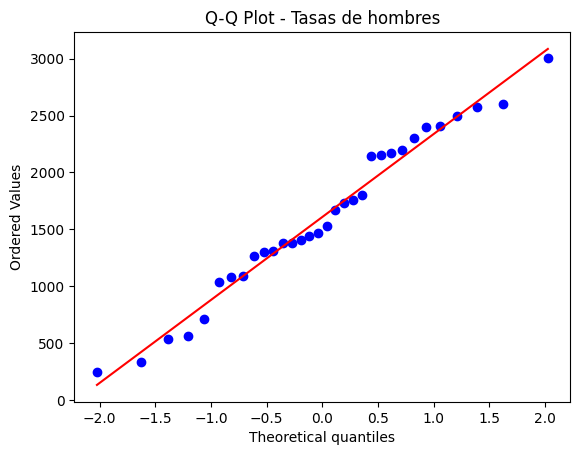

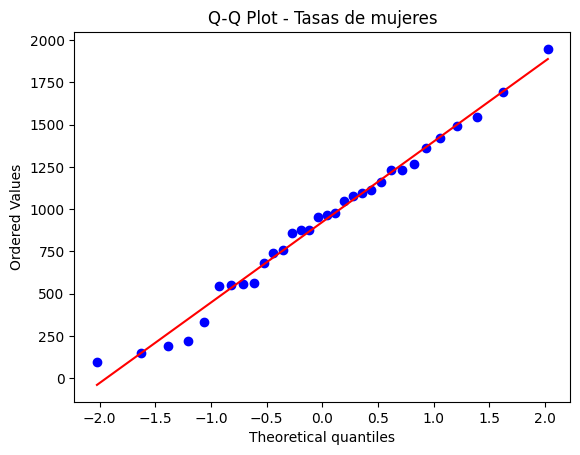

In [36]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

probplot(hombres, dist="norm", plot=plt)
plt.title("Q-Q Plot - Tasas de hombres")
plt.show()

probplot(mujeres, dist="norm", plot=plt)
plt.title("Q-Q Plot - Tasas de mujeres")
plt.show()

**Se aplicó la prueba de Shapiro-Wilk*** a las tasas de víctimas masculinas y femeninas por separado. En ambos grupos se obtuvieron valores de p superiores a 0.05 (**hombres: p = 0.5886**; **mujeres: p = 0.8763**), por lo que no se rechaza la hipótesis nula.

**Ambas distribuciones son normales por lo que se pueden hacer comparaciones estadísticas**

# **Hipótesis sobre la comparación estadística:**

Para la prueba t de comparación de dos grupos:

-> **Hipótesis nula (H₀):**

No existe una diferencia estadísticamente significativa entre el promedio de la tasa de víctimas masculinas y el promedio de la tasa de víctimas femeninas por cada 100,000 habitantes.



-> **Hipótesis alternativa (H₁):**

Existe una diferencia estadísticamente significativa entre el promedio de la tasa de víctimas masculinas y el promedio de la tasa de víctimas femeninas por cada 100,000 habitantes.


# **Haciendo prueba T - Student:**


In [19]:
# separando los datos para una mayor comparacion
hombres = resultado[resultado["Sexo"]=="Hombre"]["Tasa_pregunta3"]
mujeres = resultado[resultado["Sexo"]=="Mujer"]["Tasa_pregunta3"]

In [20]:
# prueba estadistica t de Student
# Aplicar una prueba de comparación de grupos
from scipy.stats import ttest_ind

t, p = ttest_ind(hombres, mujeres)

print(p)

2.350377046059646e-05


# **RESULTADOS**

### **CRITERIO:**

-> **Si p > 0.05 → no se rechaza H₀**.

-> **Si p ≤ 0.05 → se rechaza H₀**.

**como: 0.0000235 < 0.05**

# ENTONCES SE RECHAZA LA HIPOTESIS NULA

Esto indica que existe evidencia estadística suficiente para afirmar que **la tasa promedio de víctimas masculinas y femeninas difiere significativamente**.

In [21]:
print("Media hombres:", hombres.mean())
print("Media mujeres:", mujeres.mean())

Media hombres: 1608.9763414024942
Media mujeres: 924.2963257594708


In [22]:
# ¿Es necesario decir "por cuánto"?
diferencia = hombres.mean() - mujeres.mean()
print(diferencia)


684.6800156430234


# Conclusión:
**La media de la tasa de víctimas masculinas (1608.97 por cada 100,000 habitantes) fue superior a la media de la tasa de víctimas femeninas (924.29 por cada 100,000 habitantes), lo que indica que las víctimas masculinas presentan una mayor tasa promedio.**

### ***En promedio, la tasa de victimización masculina fue 684.68 unidades mayor que la femenina, considerando la tasa por cada 100,000 habitantes***.

La prueba t de Student indicó que **existe una diferencia estadísticamente significativa entre las tasas promedio de víctimas masculinas y femeninas** (p = 0.0000235). Además, la tasa promedio de víctimas masculinas fue 684.68 unidades mayor que la tasa promedio de víctimas femeninas, considerando la tasa por cada 100,000 habitantes.

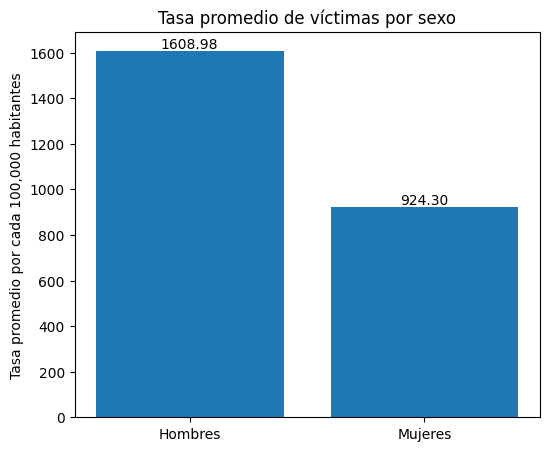

In [38]:


# Calcular las medias
media_hombres = hombres.mean()
media_mujeres = mujeres.mean()

# Crear la gráfica
plt.figure(figsize=(6,5))

plt.bar(
    ["Hombres", "Mujeres"],
    [media_hombres, media_mujeres]
)

# Escribir el valor encima de cada barra
plt.text(0, media_hombres + 10, f"{media_hombres:.2f}", ha="center")
plt.text(1, media_mujeres + 10, f"{media_mujeres:.2f}", ha="center")

plt.title("Tasa promedio de víctimas por sexo")
plt.ylabel("Tasa promedio por cada 100,000 habitantes")

plt.show()

# **4. ¿Cuál sería el estado más inseguro?**

Usamos la tasa de delitos por cada 100,000 habitantes en vez del total, para que no gane nada más por tener más población.

In [37]:
df_pregunta4 = df.copy()

In [38]:
# Sumamos todos los años y meses por estado
totales_estado = df_pregunta4.groupby('Entidad')[meses].sum().reset_index()
totales_estado['Total_delitos'] = totales_estado[meses].sum(axis=1) # axis = 1 para sumar horizontalmente

# Tasa = Total de delitos / Poblacion x 100,000
totales_estado['Poblacion'] = totales_estado['Entidad'].map(poblacion_estados)
totales_estado['Tasa'] = totales_estado['Total_delitos'] / totales_estado['Poblacion'] * 100000

tabla_estados = totales_estado[['Entidad', 'Total_delitos', 'Poblacion', 'Tasa']].sort_values('Tasa', ascending=False).reset_index(drop=True)
tabla_estados

,Entidad,Total_delitos,Poblacion,Tasa
0,Baja California,203057,3769020,5387.527792
1,México,871069,16992418,5126.221589
2,Colima,31814,731391,4349.793749
3,Querétaro,99009,2368467,4180.298902
4,Baja California Sur,32252,798447,4039.341371
5,Quintana Roo,74134,1857985,3990.021448
6,Guanajuato,245881,6166934,3987.086614
7,Aguascalientes,56673,1425607,3975.359268
8,Morelos,73945,1971520,3750.659390
9,Tabasco,86750,2402598,3610.674778


In [39]:
estado_inseguro = tabla_estados.iloc[0]
print(f"El estado más inseguro es {estado_inseguro['Entidad']}, con una tasa de {estado_inseguro['Tasa']:.1f} delitos por cada 100,000 habitantes.")

El estado más inseguro es Baja California, con una tasa de 5387.5 delitos por cada 100,000 habitantes.


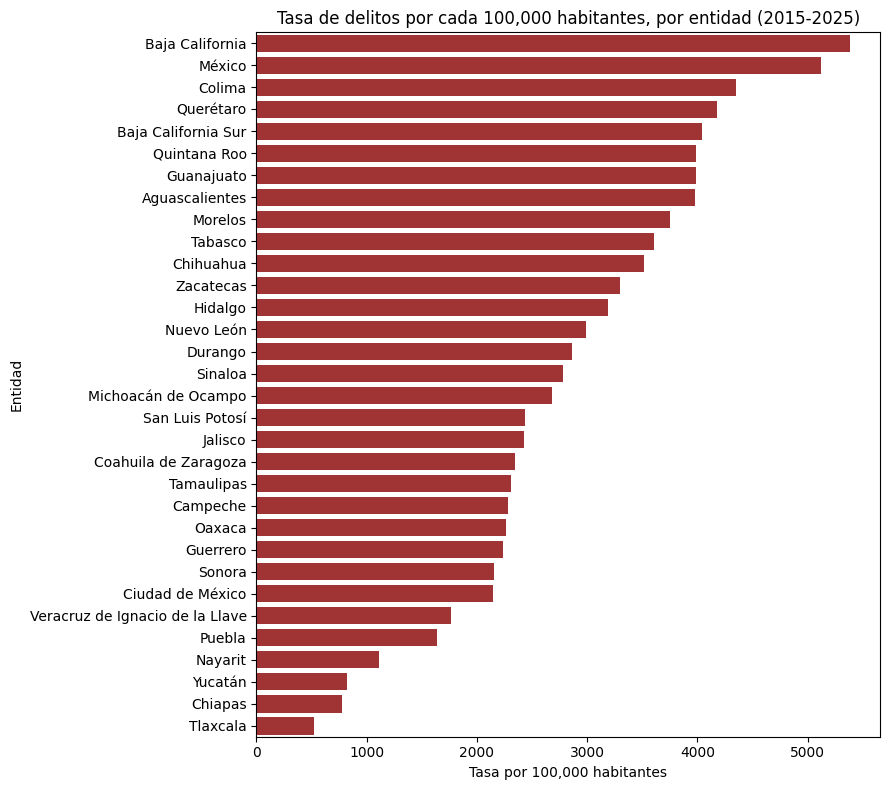

In [40]:
plt.figure(figsize=(9, 8))
sns.barplot(data=tabla_estados, x='Tasa', y='Entidad', color='firebrick')
plt.title('Tasa de delitos por cada 100,000 habitantes, por entidad (2015-2025)')
plt.xlabel('Tasa por 100,000 habitantes')
plt.ylabel('Entidad')
plt.tight_layout()
plt.show()

____


# **5.** ¿Existe una asociación significativa entre el tipo de delito cometido y el género de la víctima o son variables completamente independientes?



____

# La hipótesis de la que partimos:



-> **H₀: El tipo de delito y el sexo de la víctima son variables independientes, no existe asociación entre ellas**.

-> **H₁: El tipo de delito y el sexo de la víctima no son independientes, existe una asociación significativa entre ellas**.


In [25]:
# Crear el total de víctimas por fila
df_filtrado["Total"] = df_filtrado[meses].sum(axis=1)

C:\Users\cbi22\AppData\Local\Temp\ipykernel_41416\1021189483.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["Total"] = df_filtrado[meses].sum(axis=1)


In [26]:
# Construir la tabla de contingencia sumando victimas
tabla = (
    df_filtrado
    .groupby(["Tipo de delito", "Sexo"])["Total"]
    .sum()
    .unstack(fill_value=0)
)

print(tabla)

Sexo                                                 Hombre   Mujer
Tipo de delito                                                     
Corrupción de menores                                  7820   17218
Extorsión                                             52749   33275
Feminicidio                                               0    9166
Homicidio                                            438013   64561
Lesiones                                            1301053  942825
Otros delitos contra la sociedad                      16757   13467
Otros delitos que atentan contra la libertad pe...   128829  103458
Otros delitos que atentan contra la vida y la i...    68851   37267
Rapto                                                   143    1782
Secuestro                                              9061    3145
Trata de personas                                      1642    6025
Tráfico de menores                                      299     339


In [27]:
# aplicando el chi - cuadrado
from scipy.stats import chi2_contingency

chi2, p, gl, esperados = chi2_contingency(tabla)

print("Chi-cuadrado:", chi2)
print("p:", p)
print(f"{p:.20f}")

Chi-cuadrado: 189431.82381609286
p: 0.0
0.00000000000000000000


## **¿Cuál es el criterio?**


-> **Si p > 0.05, no se rechaza H₀**.

-> **Si p ≤ 0.05, se rechaza H₀**.

## **¿Hay suficiente evidencia para decir que existe una asociación?**

#### como:

**p < 0.05** entonces se rechaza la hipotesis nula, es decir, **hay evidencia estadística para decir que las variables están relacionadas es decir, sí hay una asociación significativa entre el sexo y el tipo de delito.**

In [28]:
print(tabla.loc["Lesiones"])

Sexo
Hombre    1301053
Mujer      942825
Name: Lesiones, dtype: int64


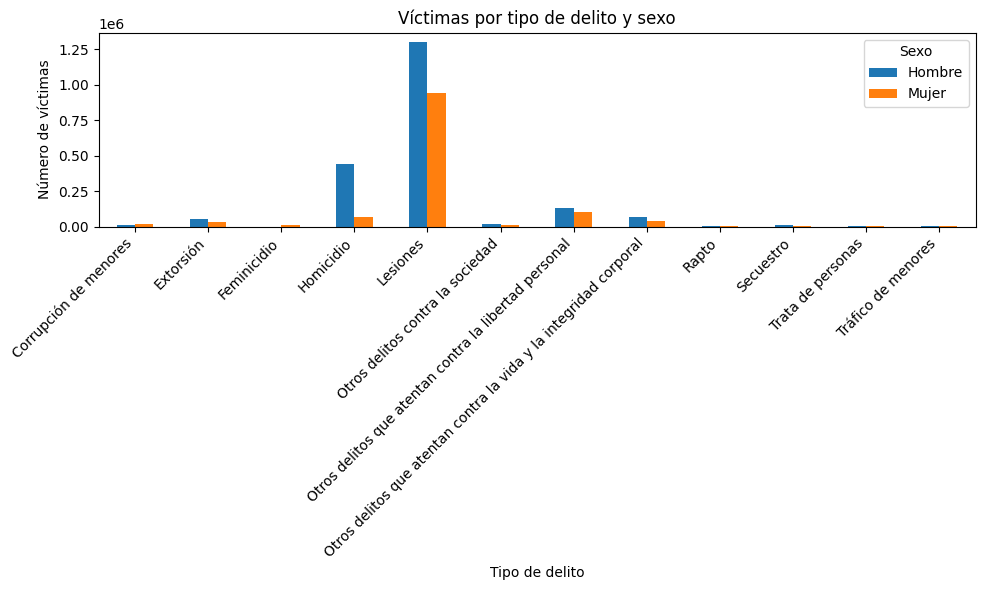

In [29]:
tabla.plot(kind="bar", figsize=(10,6))

plt.title("Víctimas por tipo de delito y sexo")
plt.xlabel("Tipo de delito")
plt.ylabel("Número de víctimas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## la grafica expresa los valores en millones de victimas

# **6. Modelar la tendencia de crecimiento o disminución de todas las victimas sin importar el tipo de delito a lo largo de los ultimos 10 años y hacer una proyeccion basica mediante regresión lineal simple**

In [45]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import matplotlib.ticker as ticker

### *Sumamos horizontalmente los 12 meses de cada registro para obtener totales anuales por fila. Posteriormente, agrupamos (groupby) toda la información del país utilizando exclusivamente la variable temporal (Año), consolidando así el volumen absoluto de víctimas a nivel nacional.*

In [47]:
#copia del dataset
df_pregunta6 = df.copy()

# Sumar los meses para tener un total por fila
df_pregunta6['Total_Anual_Fila'] = df_pregunta6[meses].sum(axis=1)

# Agrupar a nivel nacional colapsando entidades y delitos
df_tendencia = df_pregunta6.groupby('Año')['Total_Anual_Fila'].sum().reset_index()
df_tendencia.rename(columns={'Total_Anual_Fila': 'Total_Victimas'}, inplace=True)

# Revisar el dataframe resultante
print(df_tendencia)

     Año  Total_Victimas
0   2015          296318
1   2016          292812
2   2017          311565
3   2018          318749
4   2019          346275
5   2020          315570
6   2021          342320
7   2022          367065
8   2023          379169
9   2024          377251
10  2025          362450


### *Se aplica un modelo de **regresión lineal simple** donde la **variable independiente (X) es el tiempo** y **la variable dependiente (Y) es el total de víctimas**. La función linregress calcula los parámetros de la recta que mejor se ajusta a los datos históricos, permitiéndonos extraer métricas  como la **pendiente (tasa de crecimiento anual)** y el **coeficiente de determinación (R-cuadrado).***

In [48]:
# Extraer las variables como arreglos de numpy
x = df_tendencia['Año'].values
y = df_tendencia['Total_Victimas'].values

# Ejecutar el modelo de regresión lineal
modelo = linregress(x, y)

# Imprimir los estadísticos fundamentales
print("--- MÉTRICAS DEL MODELO ---")
print(f"Pendiente (Crecimiento anual promedio): {modelo.slope:,.2f} víctimas")
print(f"Intersección (Intercepto): {modelo.intercept:,.2f}")
print(f"Coeficiente de Determinación (R^2): {modelo.rvalue**2:.4f}")
print(f"Valor P (Significancia estadística): {modelo.pvalue:.4e}")

--- MÉTRICAS DEL MODELO ---
Pendiente (Crecimiento anual promedio): 8,762.77 víctimas
Intersección (Intercepto): -17,363,569.64
Coeficiente de Determinación (R^2): 0.8354
Valor P (Significancia estadística): 8.2824e-05


### *Una vez entrenado el modelo, se **extrapola la función lineal tres años hacia el futuro (2026-2028)**. La visualización gráfica superpone los datos históricos reales con la recta de ajuste y la línea de tendencia proyectada, facilitando la interpretación visual de la trayectoria delictiva y sus desviaciones coyunturales (como la observada en 2020).*


--- PROYECCIÓN DE VÍCTIMAS ---
Año 2026: 389,808 víctimas proyectadas
Año 2027: 398,571 víctimas proyectadas
Año 2028: 407,333 víctimas proyectadas


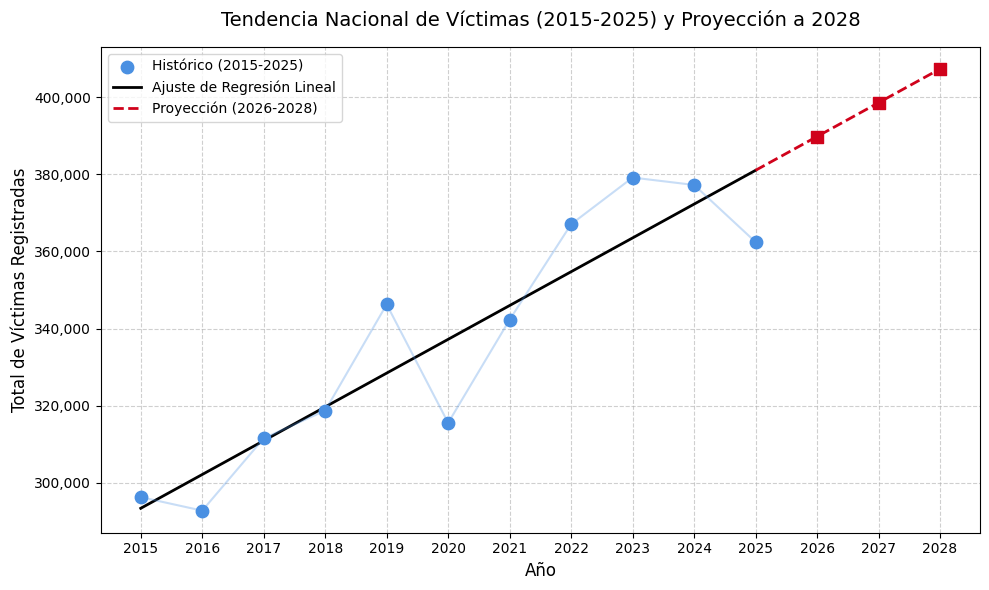

In [49]:
# Preparar los datos para la proyección futura
años_proyeccion = np.array([2026, 2027, 2028])
victimas_proyeccion = modelo.intercept + modelo.slope * años_proyeccion

# Imprimir los datos proyectados en consola
print("\n--- PROYECCIÓN DE VÍCTIMAS ---")
for anio, prediccion in zip(años_proyeccion, victimas_proyeccion):
    print(f"Año {anio}: {prediccion:,.0f} víctimas proyectadas")

# Configurar la figura del gráfico
plt.figure(figsize=(10, 6))

# Graficar datos reales (2015-2025)
plt.scatter(x, y, color='#4A90E2', s=80, label='Histórico (2015-2025)', zorder=5)
plt.plot(x, y, color='#4A90E2', alpha=0.3, zorder=4)

# Graficar la recta de ajuste del modelo
y_ajuste = modelo.intercept + modelo.slope * x
plt.plot(x, y_ajuste, color='black', linewidth=2, label='Ajuste de Regresión Lineal')

# Graficar la proyección (2026-2028) uniendo el último punto real con el futuro
x_futuro_completo = np.concatenate(([x[-1]], años_proyeccion))
y_futuro_completo = np.concatenate(([y_ajuste[-1]], victimas_proyeccion))

plt.plot(x_futuro_completo, y_futuro_completo, 
         color='#D0021B', linestyle='--', linewidth=2, label='Proyección (2026-2028)')
plt.scatter(años_proyeccion, victimas_proyeccion, color='#D0021B', s=80, marker='s', zorder=5)

# 3. Formato y estética del gráfico
plt.title('Tendencia Nacional de Víctimas (2015-2025) y Proyección a 2028', fontsize=14, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de Víctimas Registradas', fontsize=12)

# Formatear el eje Y con comas para los miles
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: format(int(val), ',')))

# Ajustar las etiquetas del eje X para que muestren todos los años
todos_los_años = np.concatenate((x, años_proyeccion))
plt.xticks(todos_los_años)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Mostrar la gráfica final
plt.show()

## *Análisis de resultados*

-> **Métricas del Modelo**: 
- **Pendiente**: Representa el ritmo de cambio. En el contexto de lo que estamos hablando, esto representa que a nivel nacional y agrupando todos los delitos, se sumaron en promedio **8,762 víctimas nuevas cada año durante la última década**, lo que representa una tendencia alcista.

- **Coeficiente de Determinación (R²)**: Indica que tan bien se ajusta la línea negra a los puntos azules. Un R² de 83.5% es inusualmente alto para fenómenos sociales. El incre4mento sostenido de las víctimas se explica por la progresión del tiempo. 

- **significancia estadística (Valor p)**: Al ser un número pequeño, se rechaza la hipótesis nula de que el incremento anual es producto de fluctuaciones aleatorias.

-> **Interpretación de la proyección (2026 - 2028)**: Extrapolando la ecuación de la recta, el modelo predice que **para finales de  2026 rozaremos la cifra de 389,800 víctimas**, y continuará escalando hasta **superar las 407,300 víctimas en 2028**.


-> **¿Y si cambia el resultado para el 2028 a la baja?**: Significará empíricamente que **hubo intervenciones o cambios estructurales que lograron romper la inercia matemática de la década anterior**. De lo contrario, el sistema habrá operado en piloto automático, cumpliendo la profecía de nuestra regresión simple. 

___

# **Conclusión**

El análisis mostró que la incidencia delictiva no se ha mantenido estable a lo largo del tiempo, se encontró un aumento significativo en la tasa de delitos, lo que indica que la inseguridad del país ha ido en aumento de forma consistente en los últimos años.
Nuestro análisis sugiere que la inseguridad en México es un fenómeno tanto temporal como geográfico, ha crecido con el paso de los años, especialmente después de la pandemia y se concentra de forma desporporcionada en ciertos estados más que en otros.


Por otro lado, es importante recalcar que el número de homicidios no es un evento ocasional, es decir es un hecho que se mantiene en el país a lo largo de todo el año sin importar estación. Además la proyección realizada con la regresión lineal no muestra números alentadores, por lo que es claro que se requieren reestructuraciones en las estrategias de seguridad implementadas por el gobierno.
Si bien los alcances de este reporte no contempla aspectos culturales ni sociológicos sería importante preguntarse si ¿Somos un país intrínsicamente violento o si es acaso que toda la población es víctima de los malos gobiernos?


Con base en el estudio estadístico que se realizó se puede afirmar que hay una clara diferencia entre número de víctimas que hay entre hombres y mujeres, los hombres tienen mayor riesgo de sufrir algún incidente. Además se encontró una asociación significativa entre el tipo de delito y el sexo de la víctima, los datos indican que existen delitos en los que la tasa de víctimas es mayor en hombres, como homicidio y lesiones, mientras que las mujeres tienen un caso particular que es el feminicidio, el registro de hombres es nulo mietras que el registro de las mujeres es alto, esto se debe a que el delito del feminicidio se registra únicamente cuando la víctima es mujer, por lo que no existen registros de hombres en esta categoría.
